Лучшие варианты каждого подхода (выбраны по результатам exp01-exp03):
- Fine-Tuning: DistilBERT, accuracy 0.9424
- Zero-Shot:   Flan-T5 + Вопросительный промпт, accuracy 0.1688
- Few-Shot:    Flan-T5 + diverse + 10 shots, accuracy 0.5282

In [38]:
# Загрузка всех предсказаний
import pandas as pd
from pathlib import Path

# Ноутбук лежит в notebooks/, results — на уровень выше
RESULTS_DIR = Path("../../results/metrics")

# Загрузка трёх файлов предсказаний
exp01 = pd.read_csv(RESULTS_DIR / "exp01_predictions.csv")
exp02 = pd.read_csv(RESULTS_DIR / "exp02_zeroshot_results.csv")
exp03 = pd.read_csv(RESULTS_DIR / "exp03_predictions.csv")

print(f"Fine-Tuning: {len(exp01)} строк, колонки: {list(exp01.columns)}")
print(f"Zero-Shot:   {len(exp02)} строк, колонки: {list(exp02.columns)}")
print(f"Few-Shot:    {len(exp03)} строк, колонки: {list(exp03.columns)}")

# Единый df для анализа
df = pd.DataFrame({
    "text": exp01["text"],
    "true_intent": exp01["true_intent"],
    "pred_ft": exp01["pred_finetuning"],
    "pred_zs": exp02["pred_prompt3"],
    "pred_fs": exp03["pred_diverse_10shot"],
})

df["correct_ft"] = (df["true_intent"] == df["pred_ft"]).astype(int)
df["correct_zs"] = (df["true_intent"] == df["pred_zs"]).astype(int)
df["correct_fs"] = (df["true_intent"] == df["pred_fs"]).astype(int)


# Краткая статистика ошибок
n_ft = (df["correct_ft"] == 0).sum()
n_zs = (df["correct_zs"] == 0).sum()
n_fs = (df["correct_fs"] == 0).sum()
n_all = ((df["correct_ft"] == 0) & (df["correct_zs"] == 0) & (df["correct_fs"] == 0)).sum()

print(f"\nОшибок Fine-Tuning: {n_ft:>4d}  ({n_ft/len(df)*100:>4.1f}%)")
print(f"Ошибок Zero-Shot:   {n_zs:>4d}  ({n_zs/len(df)*100:>4.1f}%)")
print(f"Ошибок Few-Shot:    {n_fs:>4d}  ({n_fs/len(df)*100:>4.1f}%)")
print(f"Все 3 ошиблись:     {n_all:>4d}  ({n_all/len(df)*100:>4.1f}%) база для Метода A")

df.head()

Fine-Tuning: 3578 строк, колонки: ['text', 'true_intent', 'pred_finetuning', 'correct_finetuning']
Zero-Shot:   3578 строк, колонки: ['text', 'true_intent', 'pred_prompt1', 'correct_prompt1', 'pred_prompt2', 'correct_prompt2', 'pred_prompt3', 'correct_prompt3']
Few-Shot:    3578 строк, колонки: ['text', 'true_intent', 'pred_random_1shot', 'pred_central_1shot', 'pred_diverse_1shot', 'pred_random_3shot', 'pred_central_3shot', 'pred_diverse_3shot', 'pred_random_5shot', 'pred_central_5shot', 'pred_diverse_5shot', 'pred_random_10shot', 'pred_central_10shot', 'pred_diverse_10shot']

Ошибок Fine-Tuning:  206  ( 5.8%)
Ошибок Zero-Shot:   2974  (83.1%)
Ошибок Few-Shot:    1688  (47.2%)
Все 3 ошиблись:      138  ( 3.9%) база для Метода A


,text,true_intent,pred_ft,pred_zs,pred_fs,correct_ft,correct_zs,correct_fs
0,yearly salary,income,income,redeem_rewards,w2,1,0,0
1,how do i activate you,what_is_your_name,reset_settings,what_can_i_ask_you,recipe,0,0,0
2,y check engine light currently came on and i n...,schedule_maintenance,schedule_maintenance,whisper_mode,schedule_maintenance,1,0,1
3,please suggest meals from italy to me,meal_suggestion,meal_suggestion,travel_suggestion,yes,1,0,0
4,what's the highest building in the world,oos,oos,fun_fact,directions,1,0,0


## Confusion Matrix

Всего интентов: 151


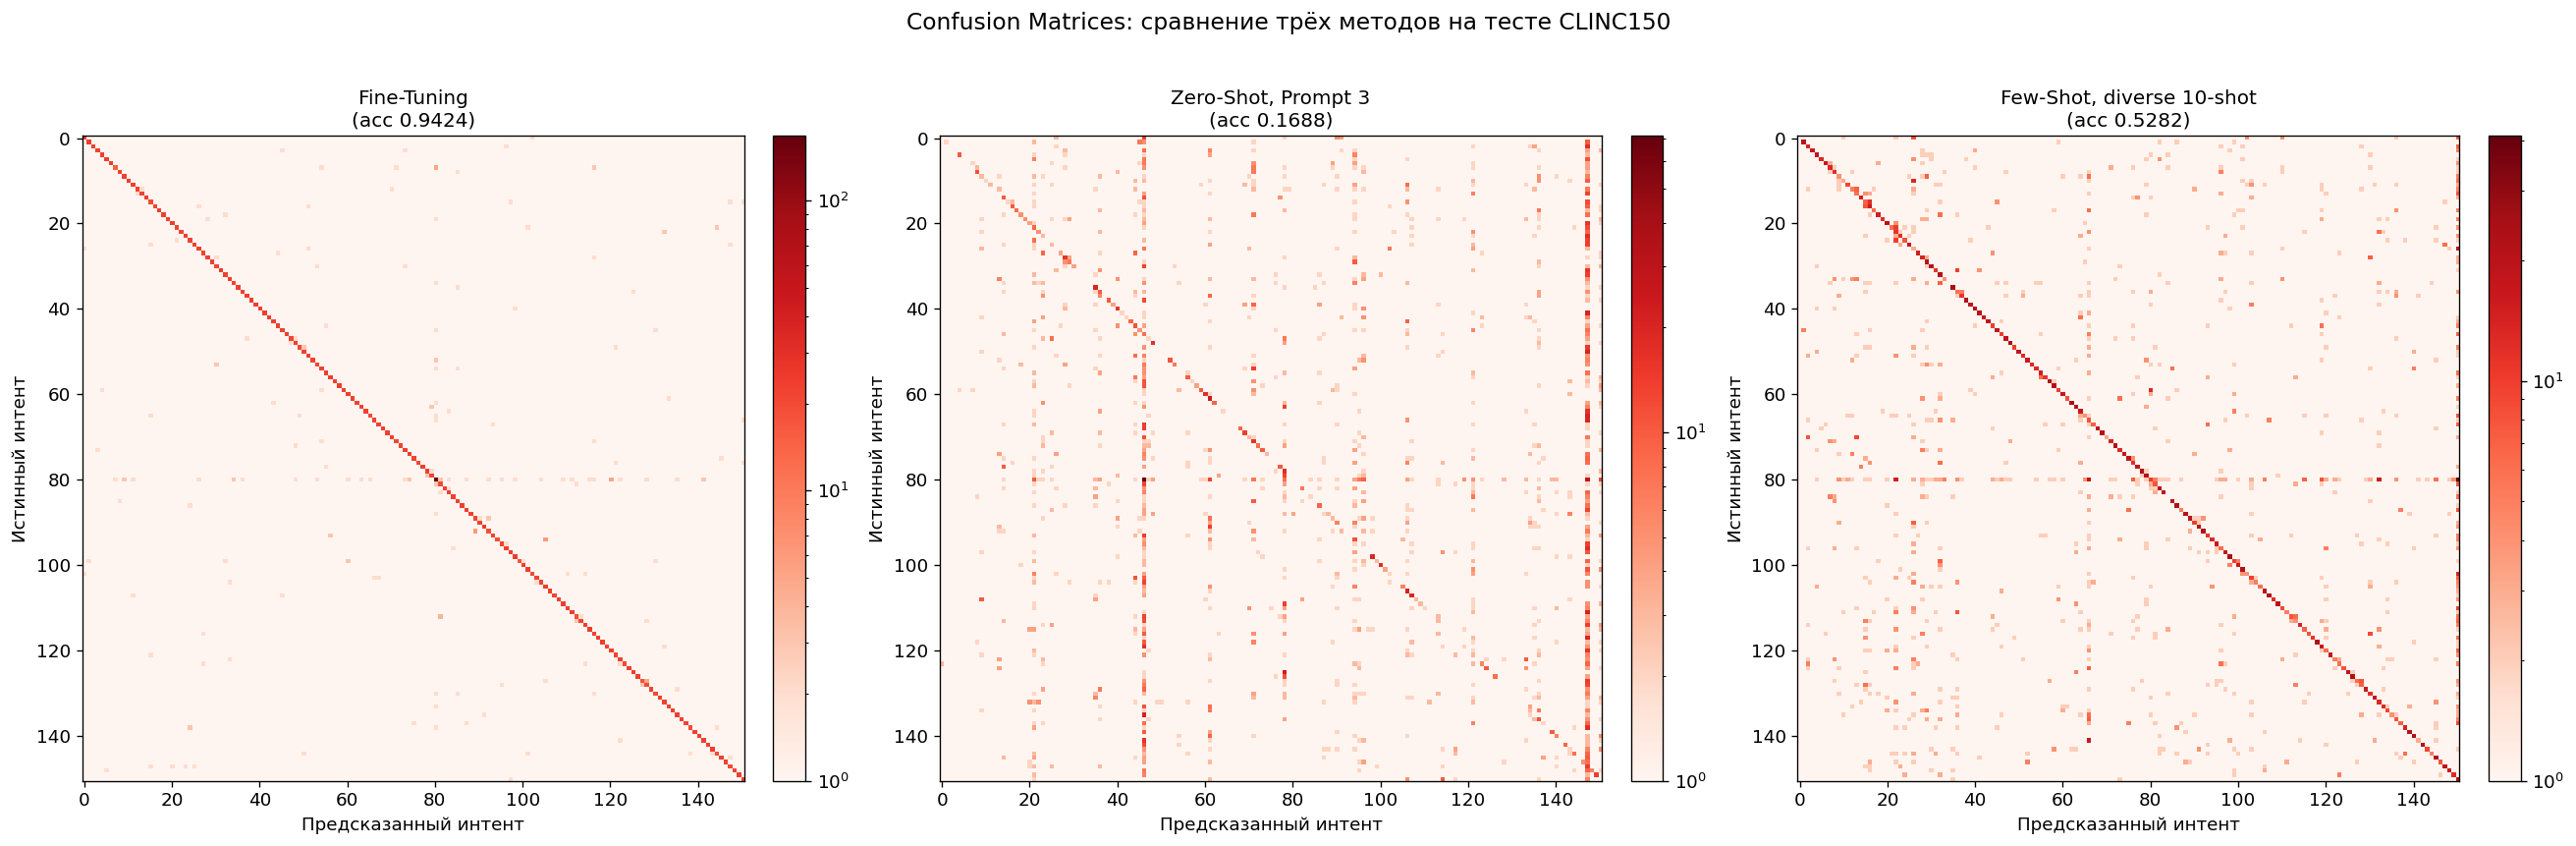

In [39]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix

# Единый алфавитный порядок интентов для всех трёх CM
all_intents = sorted(df["true_intent"].unique())
n_intents = len(all_intents)
print(f"Всего интентов: {n_intents}")

cm_ft = confusion_matrix(df["true_intent"], df["pred_ft"], labels=all_intents)
cm_zs = confusion_matrix(df["true_intent"], df["pred_zs"], labels=all_intents)
cm_fs = confusion_matrix(df["true_intent"], df["pred_fs"], labels=all_intents)

ARTIFACTS_DIR = Path("../../results/analysis")
np.save(ARTIFACTS_DIR / "cm_ft.npy", cm_ft)
np.save(ARTIFACTS_DIR / "cm_zs.npy", cm_zs)
np.save(ARTIFACTS_DIR / "cm_fs.npy", cm_fs)
(ARTIFACTS_DIR / "intents.txt").write_text("\n".join(all_intents))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

method_data = [
    (cm_ft, "Fine-Tuning\n(acc 0.9424)"),
    (cm_zs, "Zero-Shot, Prompt 3\n(acc 0.1688)"),
    (cm_fs, "Few-Shot, diverse 10-shot\n(acc 0.5282)"),
]

for ax, (cm, title) in zip(axes, method_data):
    # +1 чтобы избежать log(0)
    im = ax.imshow(cm + 1, cmap="Reds", norm=LogNorm(), aspect="auto")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Предсказанный интент")
    ax.set_ylabel("Истинный интент")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Confusion Matrices: сравнение трёх методов на тесте CLINC150",
             fontsize=14, y=1.02)
plt.tight_layout()

PLOTS_DIR = Path("../../results/plots")
plt.savefig(PLOTS_DIR / "exp04_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Пересечение ошибок трёх методов

Уникальных пар ошибок:
Fine-Tuning:  167
Zero-Shot: 1012
Few-Shot:  835

Пар, на которых ошиблись ВСЕ ТРИ метода: 15

Топ-10 пар по пересечению (сорт. по total)
    true_intent          pred_intent  n_ft  n_zs  n_fs  total
  change_volume         whisper_mode     1    13     5     19
oil_change_when       oil_change_how     2    12     1     15
         cancel         whisper_mode     1    11     1     13
      cook_time            food_last     1     8     3     12
       calendar      calendar_update     1     2     6      9
 redeem_rewards      rewards_balance     5     2     2      9
   bill_balance          min_payment     1     6     2      9
  shopping_list shopping_list_update     1     2     5      8
            oos             reminder     1     6     1      8
       pto_used          pto_balance     5     1     2      8


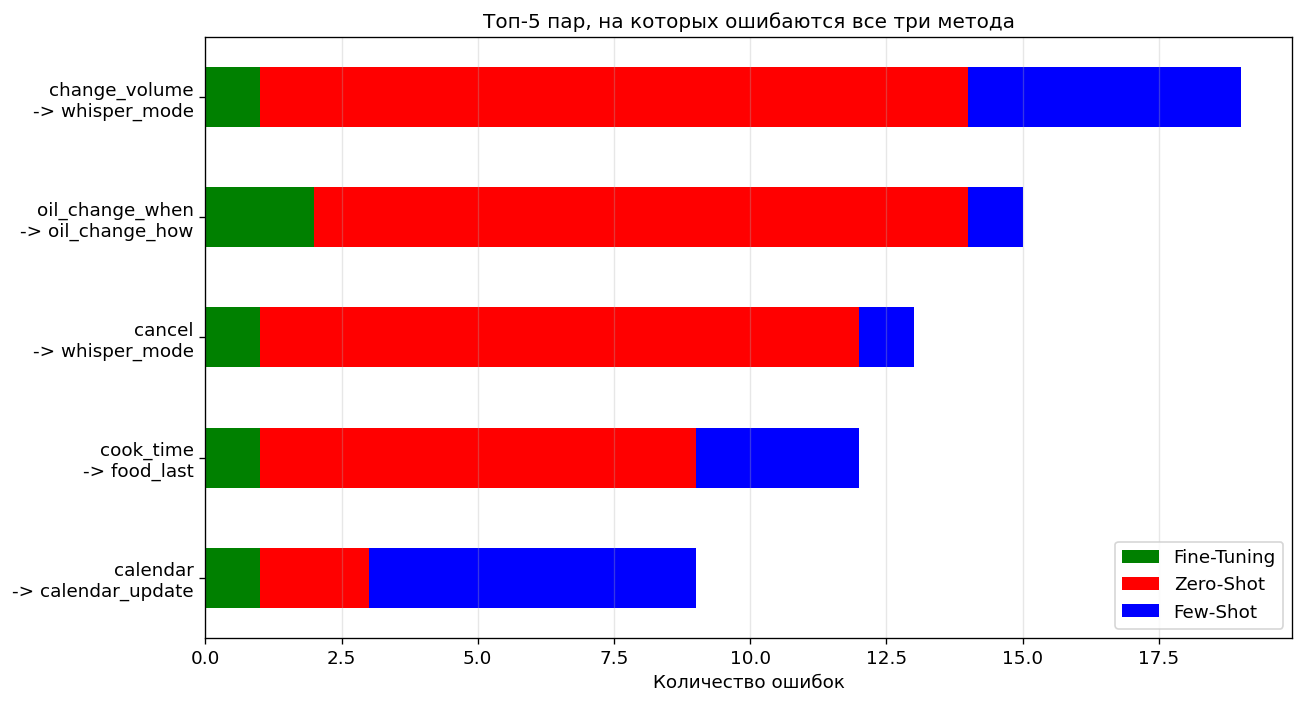

In [40]:
"""
Для каждого метода строим множество error pairs (true_intent -> pred_intent)
с частотами. Пересечение этих множеств = пары, где все три метода
сваливаются в одну и ту же ошибку. Ранжируем по сумме частот.
"""

def error_pairs_with_freq(df, pred_col):
    errs = df[df["true_intent"] != df[pred_col]]
    return errs.groupby(["true_intent", pred_col]).size()

ft_errors = error_pairs_with_freq(df, "pred_ft")
zs_errors = error_pairs_with_freq(df, "pred_zs")
fs_errors = error_pairs_with_freq(df, "pred_fs")

print(f"Уникальных пар ошибок:")
print(f"Fine-Tuning: {len(ft_errors):>4d}")
print(f"Zero-Shot: {len(zs_errors):>4d}")
print(f"Few-Shot: {len(fs_errors):>4d}")

# Пересечение трёх множеств
common_pairs = set(ft_errors.index) & set(zs_errors.index) & set(fs_errors.index)
print(f"\nПар, на которых ошиблись ВСЕ ТРИ метода: {len(common_pairs)}")

# Собираем датафрейм с разбивкой по методам
rows = []
for pair in common_pairs:
    true_intent, pred_intent = pair
    n_ft = int(ft_errors.get(pair, 0))
    n_zs = int(zs_errors.get(pair, 0))
    n_fs = int(fs_errors.get(pair, 0))
    rows.append({
        "true_intent": true_intent,
        "pred_intent": pred_intent,
        "n_ft":  n_ft,
        "n_zs":  n_zs,
        "n_fs":  n_fs,
        "total": n_ft + n_zs + n_fs,
    })

method_a_df = (
    pd.DataFrame(rows)
    .sort_values("total", ascending=False)
    .reset_index(drop=True)
)

method_a_df.to_csv(ARTIFACTS_DIR / "method_a_pairs.csv", index=False)

# Топ-10 для обзора
print("\nТоп-10 пар по пересечению (сорт. по total)")
print(method_a_df.head(10).to_string(index=False))

# Визуализация топ-5
top5_a = method_a_df.head(5).copy()
top5_a["pair"] = top5_a["true_intent"] + "\n-> " + top5_a["pred_intent"]

fig, ax = plt.subplots(figsize=(11, 6))
top5_a.set_index("pair")[["n_ft", "n_zs", "n_fs"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["green", "red", "blue"],
)
ax.set_xlabel("Количество ошибок")
ax.set_ylabel("")
ax.set_title("Топ-5 пар, на которых ошибаются все три метода",
             fontsize=12)
ax.legend(["Fine-Tuning", "Zero-Shot", "Few-Shot"], loc="lower right")
ax.invert_yaxis()  # самая частая пара — сверху
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "exp04_method_a_top5.png",
            dpi=200, bbox_inches="tight")
plt.show()

## Агрегированная частота ошибок
### Подход: каждый confusion matrix нормализуем построчно (вероятность ошибки внутри класса), суммируем три нормализованных CM и берём топ off-diagonal клеток.

### Ключевое условие — фильтр participation: пара учитывается, только если ОШИБАЮТСЯ >= 2 МЕТОДА ИЗ 3. Без этого фильтра топ занимают catastrophic failures одного метода, что показывает слабость метода, а не сложность пары.

Топ-10 пар по агрегированной частоте (фильтр: ≥2 методов confuse)
      true_intent        pred_intent  n_methods  rate_ft  rate_zs  rate_fs  total
travel_suggestion           fun_fact          2    0.000    0.870    0.043  0.913
    change_volume       whisper_mode          3    0.043    0.565    0.217  0.826
        tell_joke           fun_fact          2    0.000    0.727    0.045  0.773
  oil_change_when     oil_change_how          3    0.091    0.545    0.045  0.682
           cancel cancel_reservation          2    0.000    0.091    0.500  0.591
           cancel       whisper_mode          3    0.045    0.500    0.045  0.591
 current_location         directions          2    0.000    0.174    0.391  0.565
   nutrition_info           calories          2    0.000    0.391    0.174  0.565
        cook_time          food_last          3    0.045    0.364    0.136  0.545
        todo_list   todo_list_update          2    0.182    0.000    0.318  0.500


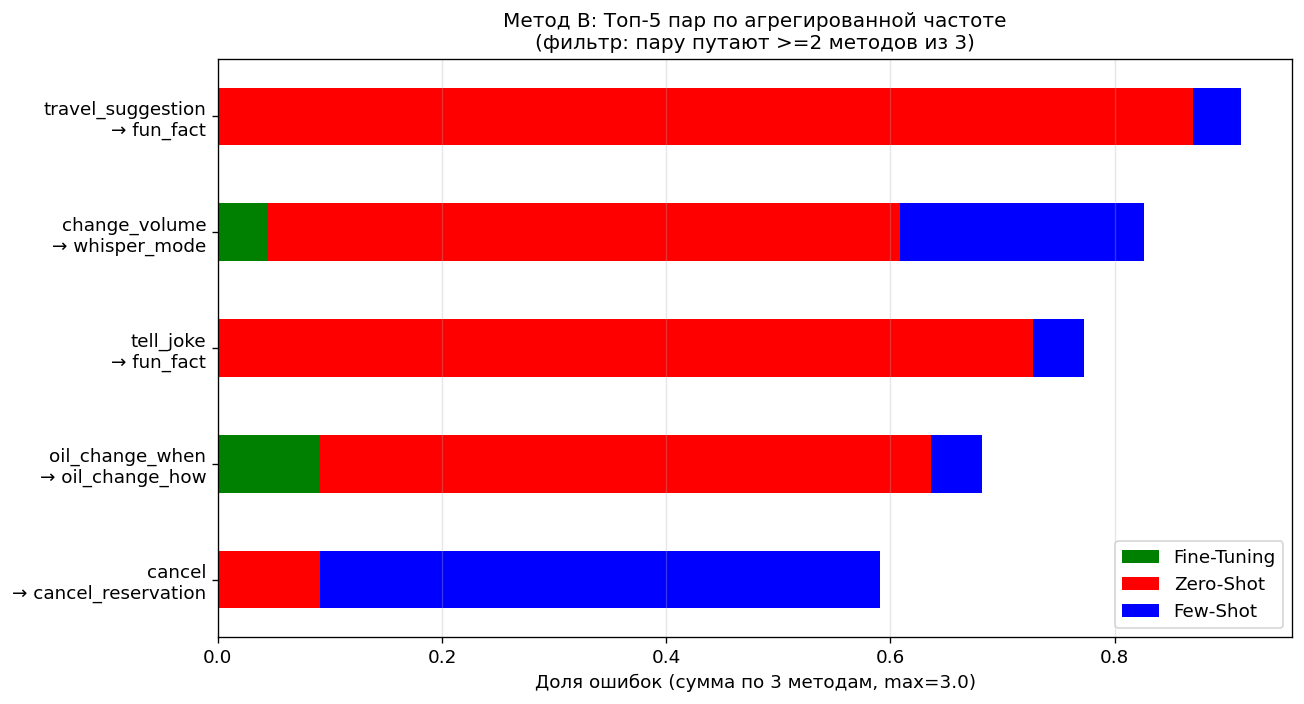

In [41]:
def row_normalize(cm):
    # Каждая строка CM - распределение предсказаний (сумма=1)
    row_sums = cm.sum(axis=1, keepdims=True)
    return np.divide(cm, row_sums,
                     out=np.zeros_like(cm, dtype=float),
                     where=row_sums > 0)

# Row-normalize все три CM
cm_ft_norm = row_normalize(cm_ft)
cm_zs_norm = row_normalize(cm_zs)
cm_fs_norm = row_normalize(cm_fs)

# Считаем, сколько методов confuses каждую пару
n_methods_confused = (
    (cm_ft_norm > 0).astype(int) +
    (cm_zs_norm > 0).astype(int) +
    (cm_fs_norm > 0).astype(int)
)

# Сумма нормализованных rate-ов с фильтром ">=2 методов"
cm_agg = cm_ft_norm + cm_zs_norm + cm_fs_norm
cm_agg = np.where(n_methods_confused >= 2, cm_agg, 0)
np.fill_diagonal(cm_agg, 0)  # ошибки = off-diagonal

# Топ-10 пар
top_idx = np.argsort(cm_agg.flatten())[::-1][:10]
rows = []
for idx in top_idx:
    i, j = np.unravel_index(idx, cm_agg.shape)
    if cm_agg[i, j] == 0:
        continue
    rows.append({
        "true_intent": all_intents[i],
        "pred_intent": all_intents[j],
        "n_methods": int(n_methods_confused[i, j]),
        "rate_ft": cm_ft_norm[i, j],
        "rate_zs": cm_zs_norm[i, j],
        "rate_fs": cm_fs_norm[i, j],
        "total": cm_agg[i, j],
    })

method_b_df = pd.DataFrame(rows)
method_b_df.to_csv(ARTIFACTS_DIR / "method_b_pairs.csv", index=False)

print("Топ-10 пар по агрегированной частоте (фильтр: ≥2 методов confuse)")
print(method_b_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Визуализация топ-5
top5_b = method_b_df.head(5).copy()
top5_b["pair"] = top5_b["true_intent"] + "\n→ " + top5_b["pred_intent"]

fig, ax = plt.subplots(figsize=(11, 6))
top5_b.set_index("pair")[["rate_ft", "rate_zs", "rate_fs"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["green", "red", "blue"],
)
ax.set_xlabel("Доля ошибок (сумма по 3 методам, max=3.0)")
ax.set_ylabel("")
ax.set_title("Метод B: Топ-5 пар по агрегированной частоте\n(фильтр: пару путают >=2 методов из 3)",
             fontsize=12)
ax.legend(["Fine-Tuning", "Zero-Shot", "Few-Shot"], loc="lower right")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "exp04_method_b_top5.png",
            dpi=200, bbox_inches="tight")
plt.show()

## Сравнение двух методов и сборка финального списка

### Пары, попавшие в ОБА топа — самые надёжные. Это пары, которые независимо подтверждают свою сложность двумя методологически разными подходами.
### Итоговый список = объединение обоих топ-5.

Размер пересечения двух топ-5: 2
Только в методе пересечения: 3
Только в агрегированной: 3
Финальный список (union): 8 пар

Robust pairs — в обоих топах
  change_volume             -> whisper_mode
  oil_change_when           -> oil_change_how

Только в методе пересечения ошибок
  cancel                    -> whisper_mode
  cook_time                 -> food_last
  calendar                  -> calendar_update

Только в методе агрегированной частоты
  cancel                    -> cancel_reservation
  tell_joke                 -> fun_fact
  travel_suggestion         -> fun_fact

Итоговый список пар для дальнейшего анализа
      true_intent        pred_intent  in_intersection  in_aggregated  is_robust
    change_volume       whisper_mode             True           True       True
  oil_change_when     oil_change_how             True           True       True
        cook_time          food_last             True          False      False
         calendar    calendar_update             True 

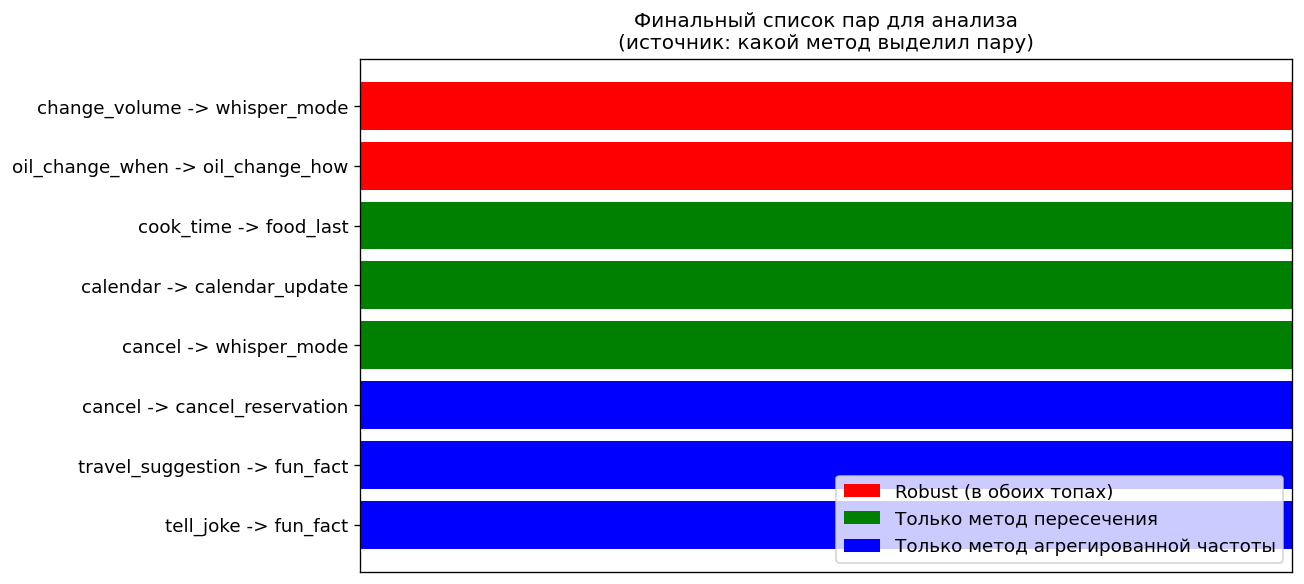

In [42]:
# Топ-5 каждого метода как множества пар
intersection_top5 = set(map(tuple, method_a_df.head(5)[["true_intent", "pred_intent"]].values))
aggregated_top5   = set(map(tuple, method_b_df.head(5)[["true_intent", "pred_intent"]].values))

# Разбиение на три группы
robust_pairs       = intersection_top5 & aggregated_top5
only_intersection  = intersection_top5 - aggregated_top5
only_aggregated    = aggregated_top5 - intersection_top5

print(f"Размер пересечения двух топ-5: {len(robust_pairs)}")
print(f"Только в методе пересечения: {len(only_intersection)}")
print(f"Только в агрегированной: {len(only_aggregated)}")
print(f"Финальный список (union): {len(intersection_top5 | aggregated_top5)} пар")

print("\nRobust pairs — в обоих топах")
for t, p in robust_pairs:
    print(f"  {t:25s} -> {p}")

print("\nТолько в методе пересечения ошибок")
for t, p in only_intersection:
    print(f"  {t:25s} -> {p}")

print("\nТолько в методе агрегированной частоты")
for t, p in only_aggregated:
    print(f"  {t:25s} -> {p}")

# Финальный датафрейм с разметкой источника
all_pairs = intersection_top5 | aggregated_top5
final_rows = []
for true_i, pred_i in all_pairs:
    in_inter = (true_i, pred_i) in intersection_top5
    in_agg   = (true_i, pred_i) in aggregated_top5
    final_rows.append({
        "true_intent": true_i,
        "pred_intent": pred_i,
        "in_intersection": in_inter,
        "in_aggregated": in_agg,
        "is_robust": in_inter and in_agg,
    })

final_pairs_df = (
    pd.DataFrame(final_rows)
    .sort_values(["is_robust", "in_intersection"], ascending=False)
    .reset_index(drop=True)
)

final_pairs_df.to_csv(ARTIFACTS_DIR / "final_pairs.csv", index=False)

print(f"\nИтоговый список пар для дальнейшего анализа")
print(final_pairs_df.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(11, 5))

# Каждая пара — горизонтальная полоска. Цвет = откуда пришла
final_pairs_df["pair"] = final_pairs_df["true_intent"] + " -> " + final_pairs_df["pred_intent"]
colors = final_pairs_df["is_robust"].map(
    lambda r: "red" if r else None
).fillna(
    final_pairs_df["in_intersection"].map(lambda x: "green" if x else "blue")
)

ax.barh(final_pairs_df["pair"], width=1, color=colors)
ax.invert_yaxis()
ax.set_xticks([])
ax.set_xlim(0, 1)

# Кастомная легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red", label="Robust (в обоих топах)"),
    Patch(facecolor="green", label="Только метод пересечения"),
    Patch(facecolor="blue", label="Только метод агрегированной частоты"),
]
ax.legend(handles=legend_elements, loc="lower right")
ax.set_title("Финальный список пар для анализа\n(источник: какой метод выделил пару)",
             fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "exp04_final_pairs.png", dpi=200, bbox_inches="tight")
plt.show()

## Сэмплинг примеров для ручной разметки типов ошибок

In [43]:
SAMPLES_PER_PAIR = 8

all_samples = []
for _, pair_row in final_pairs_df.iterrows():
    true_i = pair_row["true_intent"]
    pred_i = pair_row["pred_intent"]

    # Кандидаты: все примеры с этим true_intent
    candidates = df[df["true_intent"] == true_i].copy()

    # Сколько методов сделали именно эту ошибку на каждом примере
    n_methods = (
        (candidates["pred_ft"] == pred_i).astype(int) +
        (candidates["pred_zs"] == pred_i).astype(int) +
        (candidates["pred_fs"] == pred_i).astype(int)
    )
    candidates["n_methods_made_error"] = n_methods

    # Только те, где хотя бы один метод предсказал pred_intent
    candidates = candidates[candidates["n_methods_made_error"] > 0]

    # Сначала те, где сошлись все 3 (наиболее представительные случаи)
    candidates = candidates.sort_values("n_methods_made_error", ascending=False)

    for _, ex in candidates.head(SAMPLES_PER_PAIR).iterrows():
        methods_list = []
        if ex["pred_ft"] == pred_i: methods_list.append("FT")
        if ex["pred_zs"] == pred_i: methods_list.append("ZS")
        if ex["pred_fs"] == pred_i: methods_list.append("FS")

        all_samples.append({
            "pair": f"{true_i} -> {pred_i}",
            "true_intent": true_i,
            "pred_intent": pred_i,
            "text": ex["text"],
            "pred_ft": ex["pred_ft"],
            "pred_zs": ex["pred_zs"],
            "pred_fs": ex["pred_fs"],
            "methods_made_error": "+".join(methods_list),
            "n_methods": len(methods_list),
            "error_type": "",   # заполняется отдельно
            "notes": "",   # заполняется отдельно
        })

samples_df = pd.DataFrame(all_samples)
samples_df.to_csv(ARTIFACTS_DIR / "error_samples.csv", index=False)

print(f"Собрано примеров: {len(samples_df)}")
print(f"Уникальных пар: {samples_df['pair'].nunique()}")
print(f"\nРаспределение по парам:")
print(samples_df.groupby("pair").size().sort_values(ascending=False).to_string())
print(f"\nРаспределение по согласию методов (n_methods):")
print(samples_df["n_methods"].value_counts().sort_index().to_string())

print("\nПо 2 примера на каждую пару")
preview = samples_df.groupby("pair").head(2)[
    ["pair", "text", "methods_made_error"]
]
print(preview.to_string(index=False, max_colwidth=70))

Собрано примеров: 64
Уникальных пар: 8

Распределение по парам:
pair
calendar -> calendar_update          8
cancel -> cancel_reservation         8
cancel -> whisper_mode               8
change_volume -> whisper_mode        8
cook_time -> food_last               8
oil_change_when -> oil_change_how    8
tell_joke -> fun_fact                8
travel_suggestion -> fun_fact        8

Распределение по согласию методов (n_methods):
n_methods
1    51
2    13

По 2 примера на каждую пару
                             pair                                                               text methods_made_error
    change_volume -> whisper_mode                                                 turn the volume up              ZS+FS
    change_volume -> whisper_mode                                                  limit your volume              ZS+FS
oil_change_when -> oil_change_how            do you change the oil in your car more than once a year              FT+ZS
oil_change_when -> oil_change_how   

## Эмбеддинги + UMAP-визуализация

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import umap

Вовлечённые интенты (13):
  • calendar
  • calendar_update
  • cancel
  • cancel_reservation
  • change_volume
  • cook_time
  • food_last
  • fun_fact
  • oil_change_how
  • oil_change_when
  • tell_joke
  • travel_suggestion
  • whisper_mode

Точек для UMAP: 1950

Распределение по интентам:
intent_name
cancel                150
calendar              150
fun_fact              150
cancel_reservation    150
travel_suggestion     150
whisper_mode          150
tell_joke             150
change_volume         150
calendar_update       150
cook_time             150
oil_change_when       150
oil_change_how        150
food_last             150

Загрузка sentence-transformers/all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Кодируем тексты...


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Размер эмбеддингов: (1950, 384)

UMAP в 2D...


/opt/anaconda3/envs/intent-classification/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Сохранено: ../../results/analysis/umap_coords.csv


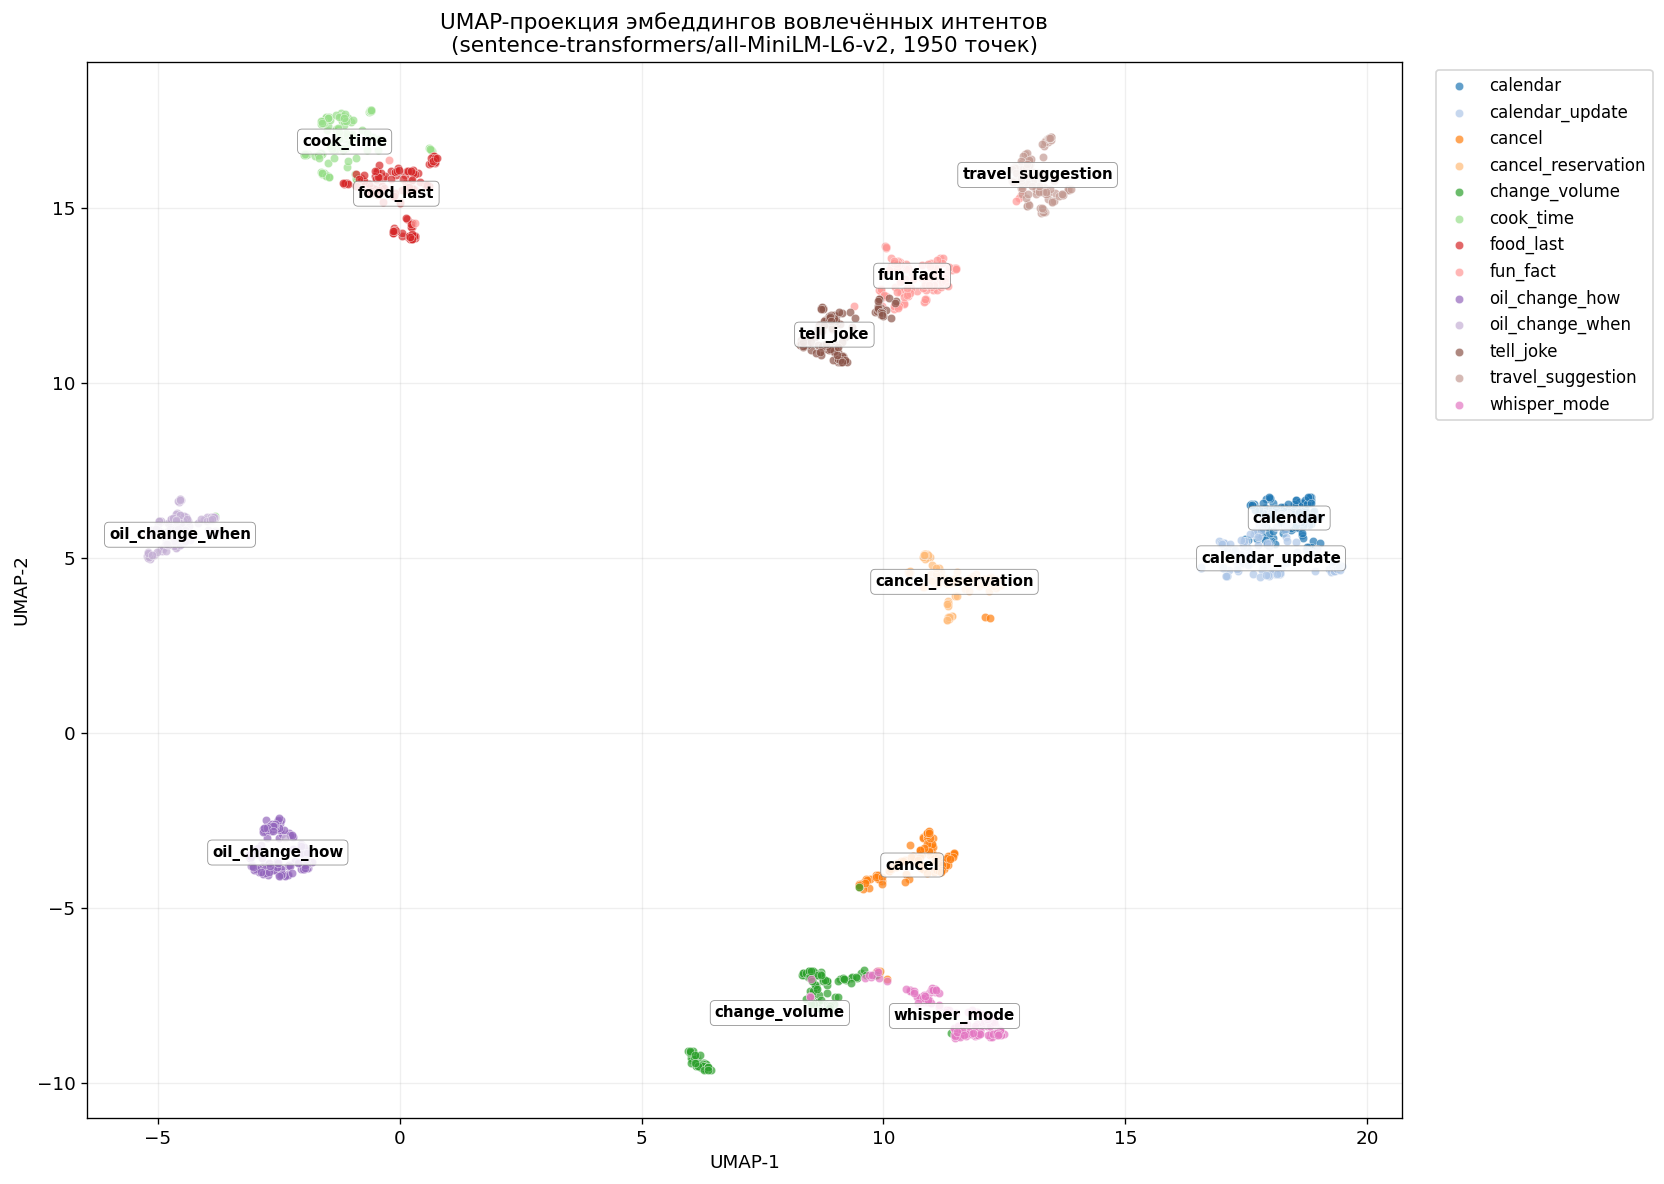

In [45]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent.parent  # notebooks/exp04_error_analysis/ → корень репо
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from src.intent_mapping import ID_TO_INTENT

# Вовлечённые интенты — объединение всех true и pred из final_pairs_df
involved_intents = sorted(
    set(final_pairs_df["true_intent"]) | set(final_pairs_df["pred_intent"])
)
print(f"Вовлечённые интенты ({len(involved_intents)}):")
for i in involved_intents:
    print(f"  • {i}")

# Загружаем все 3 сплита, фильтруем по нашим интентам
DATA_DIR = Path("../../data/splits")
parts = []
for name in ["train.csv", "val.csv", "test.csv"]:
    df_part = pd.read_csv(DATA_DIR / name)
    df_part["intent_name"] = df_part["intent"].map(ID_TO_INTENT)
    parts.append(df_part)
all_data = pd.concat(parts, ignore_index=True)

subset = (
    all_data[all_data["intent_name"].isin(involved_intents)]
    .reset_index(drop=True)
)
print(f"\nТочек для UMAP: {len(subset)}")
print(f"\nРаспределение по интентам:")
print(subset["intent_name"].value_counts().to_string())

# Эмбеддинги
print("\nЗагрузка sentence-transformers/all-MiniLM-L6-v2...")
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Кодируем тексты...")
embeddings = encoder.encode(
    subset["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Размер эмбеддингов: {embeddings.shape}")

# UMAP в 2D
print("\nUMAP в 2D...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
coords_2d = reducer.fit_transform(embeddings)
subset["umap_x"] = coords_2d[:, 0]
subset["umap_y"] = coords_2d[:, 1]

# Сохраняем для Streamlit
subset[["text", "intent_name", "umap_x", "umap_y"]].to_csv(
    ARTIFACTS_DIR / "umap_coords.csv", index=False
)
print(f"Сохранено: {ARTIFACTS_DIR / 'umap_coords.csv'}")

# Визуализация
fig, ax = plt.subplots(figsize=(14, 10))

palette = plt.cm.tab20(np.linspace(0, 1, 20))[:len(involved_intents)]
color_map = dict(zip(involved_intents, palette))

for intent in involved_intents:
    mask = subset["intent_name"] == intent
    ax.scatter(
        subset.loc[mask, "umap_x"],
        subset.loc[mask, "umap_y"],
        c=[color_map[intent]],
        label=intent,
        alpha=0.7,
        s=25,
        edgecolors="white",
        linewidths=0.3,
    )

# Подписи интентов в центроидах кластеров (для читаемости)
for intent in involved_intents:
    mask = subset["intent_name"] == intent
    cx = subset.loc[mask, "umap_x"].mean()
    cy = subset.loc[mask, "umap_y"].mean()
    ax.annotate(
        intent,
        (cx, cy),
        fontsize=9,
        weight="bold",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  alpha=0.85, edgecolor="gray", linewidth=0.5),
    )

ax.set_title(
    "UMAP-проекция эмбеддингов вовлечённых интентов\n"
    f"(sentence-transformers/all-MiniLM-L6-v2, {len(subset)} точек)",
    fontsize=13,
)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "exp04_umap_all_intents.png",
            dpi=200, bbox_inches="tight")
plt.show()

In [46]:
# Сохранение единого df для Streamlit
df.to_csv(ARTIFACTS_DIR / "unified_predictions.csv", index=False)